<a href="https://colab.research.google.com/github/naamasarshalom-art/segmentation_cellpose/blob/main/6_model2_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model 2 — Morphology Classifier (Good vs Invaginated)

This notebook trains **Model 2**: a binary classifier that distinguishes
morphologically normal nuclei (`good`) from invaginated ones (`invaginated`).

Model 2 is applied only to nuclei that passed **Model 1** quality control
(i.e., classified as `classifiable`, not `trash`).

**Input:** DINOv2 CLS embeddings computed in notebook `5_DINOv3_embeddings.ipynb`

**Pipeline:**
1. Load embeddings and filter to good (0) and invaginated (1) classes
2. Train / test split
3. Visualize embedding space (PCA 2D)
4. PCA exploration (variance explained)
5. Grid search: models, hyperparameters, PCA configurations (5-fold CV on train)
6. Train final model — best config selected automatically
7. Evaluate on held-out test set
8. Save model (scaler + PCA if used + classifier)
9. Score distribution by original class

**Output files:**
- `model2_scaler.pkl` — fitted StandardScaler
- `model2_pca.pkl` — fitted PCA (only if PCA was selected as best config)
- `model2_clf.pkl` — trained classifier


## 1. Setup

In [25]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
import numpy as np
import pandas as pd
import joblib

from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_predict, cross_validate
)
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import (
    make_scorer, roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

## 2. Configuration

In [27]:
# Input embeddings produced by 4_DINOv2_embeddings.ipynb
EMBEDDINGS_PATH = "/content/drive/MyDrive/model_nuc/embeddings_dino.0.4.npz"

# Directory where the trained model will be saved
MODEL_DIR = "/content/drive/MyDrive/model_nuc"

# Only good (0) and invaginated (1) are used for Model 2.
# Unclassifiable (2) and trash (3) are excluded.
CLASS_NAMES = {0: "good", 1: "invaginated"}

RANDOM_STATE = 42

## 3. Load Data & Filter to Good vs Invaginated

In [28]:
data   = np.load(EMBEDDINGS_PATH, allow_pickle=True)
X_all  = data["X"]
labels = data["labels"]

# Keep only good (0) and invaginated (1)
mask = (labels == 0) | (labels == 1)
X = X_all[mask]
y = labels[mask]

print(f"Embedding shape: {X.shape}")
print("\nClass distribution:")
for cls, name in CLASS_NAMES.items():
    n = (y == cls).sum()
    print(f"  {name:>15}: {n:>4} samples ({100*n/len(y):.1f}%)")
print(f"  {'Total':>15}: {len(y):>4}")

Embedding shape: (150, 768)

Class distribution:
             good:   90 samples (60.0%)
      invaginated:   60 samples (40.0%)
            Total:  150


## 4. Train / Test Split

20% held-out test set — not used until final evaluation.

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Train: {len(X_train)} samples")
print(f"Test:  {len(X_test)} samples")

print("\nClass distribution:")
print(f"  {'Class':<20} {'Train':>8} {'Train%':>8} {'Test':>8} {'Test%':>8}")
print("  " + "-" * 52)
for cls, name in CLASS_NAMES.items():
    n_train = (y_train == cls).sum()
    n_test  = (y_test  == cls).sum()
    print(f"  {name:<20} {n_train:>8} {100*n_train/len(y_train):>7.1f}% {n_test:>8} {100*n_test/len(y_test):>7.1f}%")

Train: 120 samples
Test:  30 samples

Class distribution:
  Class                   Train   Train%     Test    Test%
  ----------------------------------------------------
  good                       72    60.0%       18    60.0%
  invaginated                48    40.0%       12    40.0%


## 5. Embedding Space Visualization (PCA 2D)

Project the DINOv2 embeddings to 2D to check class separability before training.

Explained variance: PC1=18.1%  PC2=9.5%


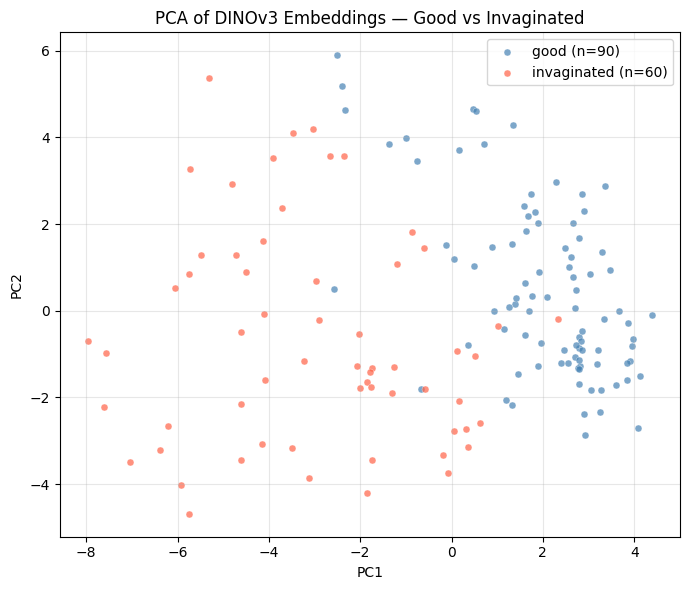

In [30]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Project to 2D
pca_viz = PCA(n_components=2, random_state=0)
X_2d    = pca_viz.fit_transform(X)

print(f"Explained variance: PC1={pca_viz.explained_variance_ratio_[0]:.1%}  "
      f"PC2={pca_viz.explained_variance_ratio_[1]:.1%}")

# Plot
COLORS = {0: "steelblue", 1: "tomato"}

plt.figure(figsize=(7, 6))
for cls, name in CLASS_NAMES.items():
    mask = y == cls
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                c=COLORS[cls],
                label=f"{name} (n={mask.sum()})",
                alpha=0.7, s=25, edgecolors="white", linewidth=0.3)

plt.title("PCA of DINOv3 Embeddings — Good vs Invaginated")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Scale Data & PCA Exploration

Scale the training data with StandardScaler (fit on train only),
then explore how many PCA components are needed to explain the variance.

  Components for 90% variance: 46
  Components for 95% variance: 65
  Components for 98% variance: 86


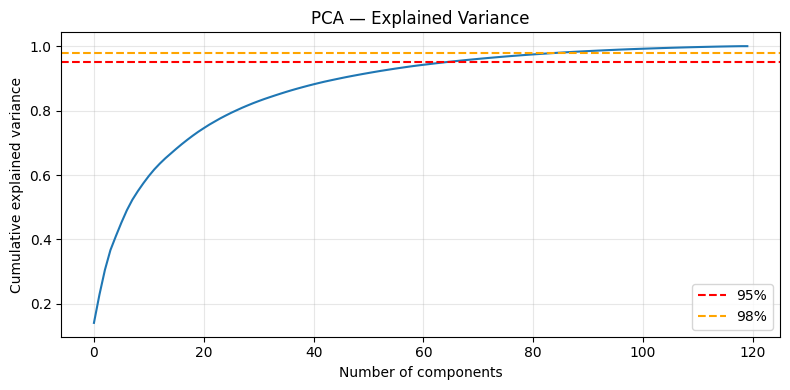

In [31]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# ── Fit PCA on scaled training data to explore variance ───────────────────
# This is for exploration only — the actual scaler used for training
# is inside each pipeline in the grid search below.
scaler_exp = StandardScaler()
X_train_exp = scaler_exp.fit_transform(X_train)

pca_exp = PCA().fit(X_train_exp)
cumvar  = np.cumsum(pca_exp.explained_variance_ratio_)

for threshold in [0.90, 0.95, 0.98]:
    n = np.argmax(cumvar >= threshold) + 1
    print(f"  Components for {threshold*100:.0f}% variance: {n}")

plt.figure(figsize=(8, 4))
plt.plot(cumvar)
plt.axhline(0.95, color='red',    linestyle='--', label='95%')
plt.axhline(0.98, color='orange', linestyle='--', label='98%')
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA — Explained Variance")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 7. Model Selection — Grid Search

Compare SVM, Logistic Regression, Random Forest, and LDA
across different hyperparameters and PCA configurations.
All evaluation is done with 5-fold cross-validation on the training set only.
The scaler is included inside each pipeline — no external scaling needed.

In [32]:
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, f1_score, recall_score, precision_score, accuracy_score
import pandas as pd

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "accuracy":               "accuracy",
    "f1_macro":               "f1_macro",
    "f1_good":           make_scorer(f1_score,        average=None, labels=[0]),
    "f1_invaginated":    make_scorer(f1_score,        average=None, labels=[1]),
    "recall_good":       make_scorer(recall_score,    average=None, labels=[0]),
    "recall_invaginated":make_scorer(recall_score,    average=None, labels=[1]),
    "precision_good":    make_scorer(precision_score, average=None, labels=[0]),
    "precision_invaginated": make_scorer(precision_score, average=None, labels=[1]),
}

PCA_OPTIONS = {
    "no_PCA": None,
    "PCA_90": 46,
    "PCA_95": 65,
    "PCA_98": 86,
}

MODELS = {
    "SVM_C0.1": SVC(kernel="rbf", C=0.1, class_weight="balanced", probability=True, random_state=RANDOM_STATE),
    "SVM_C1":   SVC(kernel="rbf", C=1.0, class_weight="balanced", probability=True, random_state=RANDOM_STATE),
    "SVM_C5":   SVC(kernel="rbf", C=5.0, class_weight="balanced", probability=True, random_state=RANDOM_STATE),
    "LR_C0.1":  LogisticRegression(C=0.1, class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE),
    "LR_C1":    LogisticRegression(C=1.0, class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE),
    "LR_C10":   LogisticRegression(C=10,  class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE),
    "RF_100":   RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=RANDOM_STATE),
    "RF_300":   RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE),
    "LDA":      LinearDiscriminantAnalysis(),
}

# Build all pipelines
CONFIGS = {}
for model_name, model in MODELS.items():
    for pca_name, n_components in PCA_OPTIONS.items():
        config_name = f"{model_name}__{pca_name}"
        steps = [("scaler", StandardScaler())]
        if n_components is not None:
            steps.append(("pca", PCA(n_components=n_components, random_state=RANDOM_STATE)))
        steps.append(("clf", model))
        CONFIGS[config_name] = Pipeline(steps)

print(f"Total configurations to test: {len(CONFIGS)}")

# ── Run cross-validation ───────────────────────────────────────────────────
results = []

for config_name, pipeline in CONFIGS.items():
    print(f"  Testing: {config_name}...")
    cv_res = cross_validate(
        pipeline, X_train, y_train,
        cv=cv, scoring=scoring,
        return_train_score=False
    )

    def fmt(key):
        vals = cv_res[f"test_{key}"].flatten()
        return f"{vals.mean():.3f}", f"{vals.std():.3f}"

    results.append({
        "config":                  config_name,
        "accuracy":                fmt("accuracy"),
        "F1 macro":                fmt("f1_macro"),
        "F1 good":           fmt("f1_good"),
        "F1 invaginated":    fmt("f1_invaginated"),
        "Recall good":       fmt("recall_good"),
        "Recall invaginated":fmt("recall_invaginated"),
        "Precision good":    fmt("precision_good"),
        "Precision invaginated": fmt("precision_invaginated"),
    })

# ── Sort by F1 macro ───────────────────────────────────────────────────────
df = pd.DataFrame(results)
df["_sort"] = df["F1 macro"].apply(lambda x: float(x[0]))
df = df.sort_values("_sort", ascending=False).drop(columns="_sort")

# ── Print ──────────────────────────────────────────────────────────────────
col_width = 18
metrics   = [c for c in df.columns if c != "config"]

print("\n" + "="*180)
print("GRID SEARCH RESULTS (5-fold CV on train set)")
print("="*180)
print(f"{'config':<35}" + "".join(f"{m:<{col_width}}" for m in metrics))
print("-"*180)

for _, row in df.iterrows():
    means = [row[m][0] for m in metrics]
    stds  = [f"± {row[m][1]}" for m in metrics]
    print(f"{row['config']:<35}" + "".join(f"{v:<{col_width}}" for v in means))
    print(f"{'  ':<35}"          + "".join(f"{s:<{col_width}}" for s in stds))
    print()

Total configurations to test: 36
  Testing: SVM_C0.1__no_PCA...
  Testing: SVM_C0.1__PCA_90...
  Testing: SVM_C0.1__PCA_95...
  Testing: SVM_C0.1__PCA_98...
  Testing: SVM_C1__no_PCA...
  Testing: SVM_C1__PCA_90...
  Testing: SVM_C1__PCA_95...
  Testing: SVM_C1__PCA_98...
  Testing: SVM_C5__no_PCA...
  Testing: SVM_C5__PCA_90...
  Testing: SVM_C5__PCA_95...
  Testing: SVM_C5__PCA_98...
  Testing: LR_C0.1__no_PCA...
  Testing: LR_C0.1__PCA_90...
  Testing: LR_C0.1__PCA_95...
  Testing: LR_C0.1__PCA_98...
  Testing: LR_C1__no_PCA...
  Testing: LR_C1__PCA_90...
  Testing: LR_C1__PCA_95...
  Testing: LR_C1__PCA_98...
  Testing: LR_C10__no_PCA...
  Testing: LR_C10__PCA_90...
  Testing: LR_C10__PCA_95...
  Testing: LR_C10__PCA_98...
  Testing: RF_100__no_PCA...
  Testing: RF_100__PCA_90...
  Testing: RF_100__PCA_95...
  Testing: RF_100__PCA_98...
  Testing: RF_300__no_PCA...
  Testing: RF_300__PCA_90...
  Testing: RF_300__PCA_95...
  Testing: RF_300__PCA_98...
  Testing: LDA__no_PCA...
  Tes

## 8. Train Final Model

Automatically select the best configuration from the grid search
and retrain it on the full training set using the complete pipeline
(scaler + optional PCA + classifier).

In [33]:
# ── Automatically select best config from grid search results ──────────────
best_row    = df.iloc[0]  # already sorted by F1 macro descending
best_config = best_row["config"]
print(f"Best config: {best_config}")

# Retrain the full best pipeline (scaler + optional PCA + clf) on all training data
import copy
best_pipeline_final = copy.deepcopy(CONFIGS[best_config])
best_pipeline_final.fit(X_train, y_train)
print(f"Model trained successfully on full training set.")
print(f"Training samples: {len(X_train)}")


Best config: LR_C10__PCA_90
Model trained successfully on full training set.
Training samples: 120


## 9. Evaluate on Test Set

Evaluate the final model once on the held-out test set.
The pipeline applies the same scaler (and PCA if used) automatically.

In [34]:
# ── Evaluate on held-out test set ─────────────────────────────────────────
y_test_pred  = best_pipeline_final.predict(X_test)
y_test_proba = best_pipeline_final.predict_proba(X_test)[:, 1]

from sklearn.metrics import (
    accuracy_score, f1_score, recall_score,
    precision_score, roc_auc_score,
    classification_report, confusion_matrix
)

print("="*50)
print("TEST SET RESULTS")
print("="*50)
print(f"  accuracy           : {accuracy_score(y_test, y_test_pred):.4f}")
print(f"  F1 macro           : {f1_score(y_test, y_test_pred, average='macro'):.4f}")
print(f"  ROC AUC            : {roc_auc_score(y_test, y_test_proba):.4f}")
print(f"  F1 good            : {f1_score(y_test, y_test_pred, average=None)[0]:.4f}")
print(f"  F1 invaginated     : {f1_score(y_test, y_test_pred, average=None)[1]:.4f}")
print(f"  Recall good        : {recall_score(y_test, y_test_pred, average=None)[0]:.4f}")
print(f"  Recall invaginated : {recall_score(y_test, y_test_pred, average=None)[1]:.4f}")
print(f"  Precision good     : {precision_score(y_test, y_test_pred, average=None)[0]:.4f}")
print(f"  Precision invaginated: {precision_score(y_test, y_test_pred, average=None)[1]:.4f}")
print()
print(classification_report(y_test, y_test_pred, target_names=["good", "invaginated"]))

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()
print(f"  Confusion Matrix:")
print(f"  {'':>20} {'pred: good':>15} {'pred: invaginated':>18}")
print(f"  {'true: good':>20} {tn:>15} {fp:>18}")
print(f"  {'true: invaginated':>20} {fn:>15} {tp:>18}")


TEST SET RESULTS
  accuracy           : 0.9333
  F1 macro           : 0.9321
  ROC AUC            : 0.9907
  F1 good            : 0.9412
  F1 invaginated     : 0.9231
  Recall good        : 0.8889
  Recall invaginated : 1.0000
  Precision good     : 1.0000
  Precision invaginated: 0.8571

              precision    recall  f1-score   support

        good       1.00      0.89      0.94        18
 invaginated       0.86      1.00      0.92        12

    accuracy                           0.93        30
   macro avg       0.93      0.94      0.93        30
weighted avg       0.94      0.93      0.93        30

  Confusion Matrix:
                            pred: good  pred: invaginated
            true: good              16                  2
     true: invaginated               0                 12


## 10. Save Model

Save all components needed for inference:
scaler, PCA (if used), and the trained classifier.

In [35]:
# ── Save Model 2 components ────────────────────────────────────────────────
import os
best_steps = best_pipeline_final.named_steps

# Save scaler (always present)
joblib.dump(best_steps['scaler'], f"{MODEL_DIR}/model2_scaler.pkl")
print(f"Saved: {MODEL_DIR}/model2_scaler.pkl")

# Save PCA only if used in best config
if 'pca' in best_steps:
    joblib.dump(best_steps['pca'], f"{MODEL_DIR}/model2_pca.pkl")
    print(f"Saved: {MODEL_DIR}/model2_pca.pkl")
else:
    print("No PCA in best config — model2_pca.pkl not saved")

# Save classifier
joblib.dump(best_steps['clf'], f"{MODEL_DIR}/model2_clf.pkl")
print(f"Saved: {MODEL_DIR}/model2_clf.pkl")


Saved: /content/drive/MyDrive/model_nuc/model2_scaler.pkl
Saved: /content/drive/MyDrive/model_nuc/model2_pca.pkl
Saved: /content/drive/MyDrive/model_nuc/model2_clf.pkl


## 11. Score Distribution by Class

Histogram of predicted P(invaginated) for each original class
(good, invaginated, Unclassifiable).
The dashed lines show the classification thresholds (0.3 and 0.8).

good: min=0.000  max=0.999  mean=0.023
invaginated: min=0.970  max=1.000  mean=0.999
Unclassifiable: min=0.000  max=1.000  mean=0.363


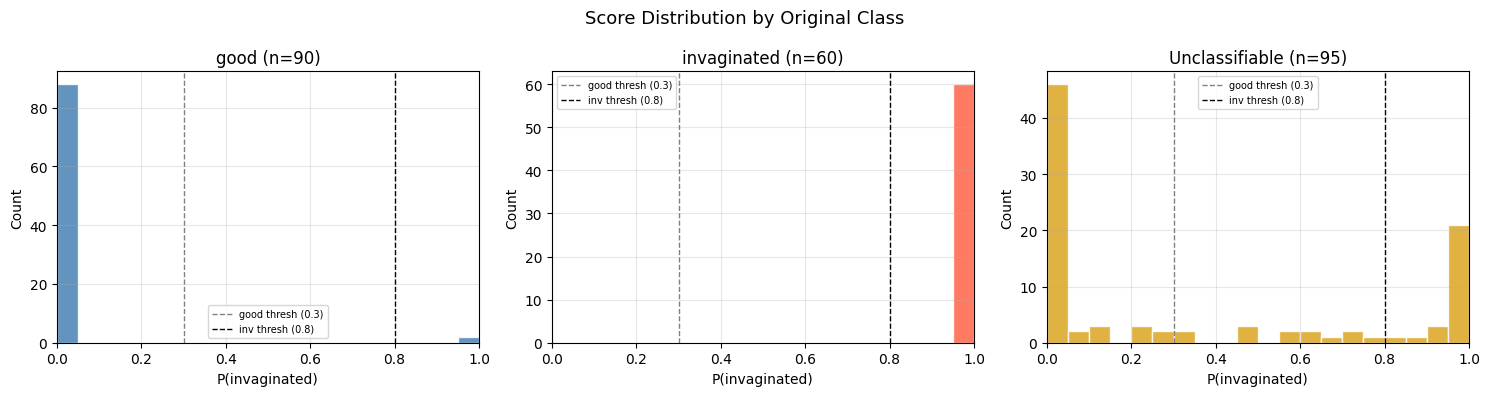

In [37]:
# ── Load ALL embeddings (all 4 classes) ────────────────────────────────────
ALL_CLASSES = {0: "good", 1: "invaginated", 2: "Unclassifiable", 3: "trash"}
COLORS_ALL  = {0: "steelblue", 1: "tomato", 2: "goldenrod", 3: "gray"}

# All samples except trash (Model 2 only runs on classifiable nuclei)
mask_all = (labels == 0) | (labels == 1) | (labels == 2)
X_all_3  = X_all[mask_all]
y_all_3  = labels[mask_all]

# Get predicted probability of invaginated
proba_all = best_pipeline_final.predict_proba(X_all_3)[:, 1]

# ── One histogram per class ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=False, sharey=False)

for ax, (cls, name) in zip(axes, {0: "good", 1: "invaginated", 2: "Unclassifiable"}.items()):
    scores = proba_all[y_all_3 == cls]
    print(f"{name}: min={scores.min():.3f}  max={scores.max():.3f}  mean={scores.mean():.3f}")

    ax.hist(scores, bins=20, range=(0, 1),
            color=COLORS_ALL[cls], edgecolor='white', alpha=0.85)
    ax.axvline(0.3, color='gray',  linestyle='--', linewidth=1, label='good thresh (0.3)')
    ax.axvline(0.8, color='black', linestyle='--', linewidth=1, label='inv thresh (0.8)')
    ax.set_xlim(0, 1)
    ax.set_title(f"{name} (n={len(scores)})")
    ax.set_xlabel("P(invaginated)")
    ax.set_ylabel("Count")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle("Score Distribution by Original Class", fontsize=13)
plt.tight_layout()
plt.show()

In [38]:
# ── Predict scores and labels for all classifiable samples ─────────────────
THRESH_GOOD        = 0.3
THRESH_INVAGINATED = 0.8

proba_all  = best_pipeline_final.predict_proba(X_all_3)[:, 1]

# Apply double threshold
pred_labels = np.where(
    proba_all < THRESH_GOOD, "good",
    np.where(proba_all > THRESH_INVAGINATED, "invaginated", "unclass")
)

# ── Print table per original class ────────────────────────────────────────
for cls, name in {0: "good", 1: "invaginated", 2: "Unclassifiable"}.items():
    mask  = y_all_3 == cls
    scores = proba_all[mask]
    preds  = pred_labels[mask]

    print(f"\n{'='*55}")
    print(f"Original class: {name} (n={mask.sum()})")
    print(f"{'='*55}")
    print(f"  {'Sample':>8} {'P(invaginated)':>16} {'Predicted as':>15}")
    print(f"  {'-'*42}")
    for i, (score, pred) in enumerate(zip(scores, preds)):
        print(f"  {i+1:>8} {score:>16.4f} {pred:>15}")

    # Summary
    print(f"\n  Summary:")
    for p in ["good", "unclass", "invaginated"]:
        n = (preds == p).sum()
        print(f"    {p:<15}: {n:>4} ({100*n/len(preds):.1f}%)")


Original class: good (n=90)
    Sample   P(invaginated)    Predicted as
  ------------------------------------------
         1           0.0000            good
         2           0.0000            good
         3           0.0000            good
         4           0.0000            good
         5           0.0001            good
         6           0.0000            good
         7           0.0035            good
         8           0.0000            good
         9           0.0061            good
        10           0.0007            good
        11           0.0000            good
        12           0.0000            good
        13           0.0000            good
        14           0.0000            good
        15           0.0134            good
        16           0.0002            good
        17           0.0001            good
        18           0.0002            good
        19           0.0004            good
        20           0.0000            good
  